In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import plotly.express as px

/Users/emilychen/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/emilychen/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/Users/emilychen/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
vehicle_df = pd.read_csv('/Users/emilychen/Downloads/csv/vehpub.csv')
household_df = pd.read_csv('/Users/emilychen/Downloads/csv/hhpub.csv')

In [3]:
vehicle_df.head()

,HOUSEID,VEHID,VEHYEAR,VEHAGE,MAKE,MODEL,FUELTYPE,VEHTYPE,WHOMAIN,OD_READ,...,HTEEMPDN,HBHTNRNT,HBPPOPDN,HBRESDN,GSYRGAL,GSTOTCST,FEGEMPG,FEGEMPGA,GSCOST,FEGEMPGF
0,30000007,1,2007,10,49,49032,1,1,3,69000,...,750,20,750,300,487.064221,1126.457778,30,-9,2.31275,1
1,30000007,2,2004,13,49,49442,1,2,-8,164000,...,750,20,750,300,250.899523,580.267873,19,-9,2.31275,1
2,30000007,3,1998,19,19,19014,1,1,1,120000,...,750,20,750,300,444.462475,1027.930589,18,-9,2.31275,1
3,30000007,4,1997,20,19,19021,1,1,2,-88,...,750,20,750,300,40.329575,93.272224,18,-9,2.31275,1
4,30000007,5,1993,24,20,20481,1,4,2,300000,...,750,20,750,300,888.404197,2054.656806,14,-9,2.31275,1


In [4]:
household_df.head()

,HOUSEID,TRAVDAY,SAMPSTRAT,HOMEOWN,HHSIZE,HHVEHCNT,HHFAMINC,PC,SPHONE,TAB,...,SMPLSRCE,WTHHFIN,HBHUR,HTHTNRNT,HTPPOPDN,HTRESDN,HTEEMPDN,HBHTNRNT,HBPPOPDN,HBRESDN
0,30000007,2,3,1,3,5,7,2,1,2,...,2,187.314320,T,50,1500,750,750,20,750,300
1,30000008,5,2,1,2,4,8,1,1,2,...,2,69.513032,R,5,300,300,150,5,300,300
2,30000012,5,3,1,1,2,10,1,1,3,...,2,79.419586,C,80,17000,17000,5000,60,17000,7000
3,30000019,5,3,1,2,2,3,1,5,5,...,2,279.143588,S,40,300,300,150,50,750,300
4,30000029,3,3,1,2,2,5,2,5,1,...,2,103.240304,S,40,1500,750,750,40,1500,750


## Missing Values

In [5]:
vehicle_df.isnull().sum()

HOUSEID      0
VEHID        0
VEHYEAR      0
VEHAGE       0
MAKE         0
MODEL        0
FUELTYPE     0
VEHTYPE      0
WHOMAIN      0
OD_READ      0
HFUEL        0
VEHOWNED     0
VEHOWNMO     0
ANNMILES     0
HYBRID       0
PERSONID     0
TRAVDAY      0
HOMEOWN      0
HHSIZE       0
HHVEHCNT     0
HHFAMINC     0
DRVRCNT      0
HHSTATE      0
HHSTFIPS     0
NUMADLT      0
WRKCOUNT     0
TDAYDATE     0
LIF_CYC      0
MSACAT       0
MSASIZE      0
RAIL         0
URBAN        0
URBANSIZE    0
URBRUR       0
CENSUS_D     0
CENSUS_R     0
CDIVMSAR     0
HH_RACE      0
HH_HISP      0
HH_CBSA      0
SMPLSRCE     0
WTHHFIN      0
BESTMILE     0
BEST_FLG     0
BEST_EDT     0
BEST_OUT     0
HBHUR        0
HTHTNRNT     0
HTPPOPDN     0
HTRESDN      0
HTEEMPDN     0
HBHTNRNT     0
HBPPOPDN     0
HBRESDN      0
GSYRGAL      0
GSTOTCST     0
FEGEMPG      0
FEGEMPGA     0
GSCOST       0
FEGEMPGF     0
dtype: int64

In [6]:
household_df.isnull().sum()

HOUSEID       0
TRAVDAY       0
SAMPSTRAT     0
HOMEOWN       0
HHSIZE        0
HHVEHCNT      0
HHFAMINC      0
PC            0
SPHONE        0
TAB           0
WALK          0
BIKE          0
CAR           0
TAXI          0
BUS           0
TRAIN         0
PARA          0
PRICE         0
PLACE         0
WALK2SAVE     0
BIKE2SAVE     0
PTRANS        0
HHRELATD      0
DRVRCNT       0
CNTTDHH       0
HHSTATE       0
HHSTFIPS      0
NUMADLT       0
YOUNGCHILD    0
WRKCOUNT      0
TDAYDATE      0
HHRESP        0
LIF_CYC       0
MSACAT        0
MSASIZE       0
RAIL          0
URBAN         0
URBANSIZE     0
URBRUR        0
SCRESP        0
CENSUS_D      0
CENSUS_R      0
CDIVMSAR      0
HH_RACE       0
HH_HISP       0
HH_CBSA       0
RESP_CNT      0
WEBUSE17      0
SMPLSRCE      0
WTHHFIN       0
HBHUR         0
HTHTNRNT      0
HTPPOPDN      0
HTRESDN       0
HTEEMPDN      0
HBHTNRNT      0
HBPPOPDN      0
HBRESDN       0
dtype: int64

##### Most variables (especially in household) are categorical 
What does each row represent in the vehicle and household dataset? How did you extract data from the survey into household and vehicle datasets?

## Univariate Analysis

In [27]:
income_dict = {1: '<10,000', 2: '10,000-14,999',
    3: '15,000-24,999', 4: '25,000-34,999',
    5: '35,000-49,999', 6: '50,000-74,999',
    7: '75,000-99,999', 8: '100,000-124,999',
    9: '125,000-149,999', 10: '150,000-199,999',
    11: '200,000+'
}
hh_count = household_df[household_df['HHFAMINC']>0]['HHFAMINC'].replace(income_dict).value_counts().reset_index()
vehicle_count = vehicle_df[vehicle_df['HHFAMINC']>0]['HHFAMINC'].replace(income_dict).value_counts().reset_index()

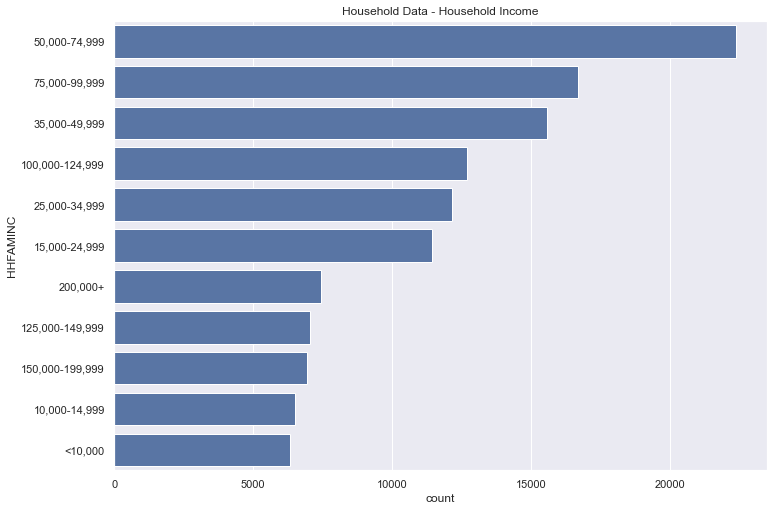

<function matplotlib.pyplot.show(close=None, block=None)>

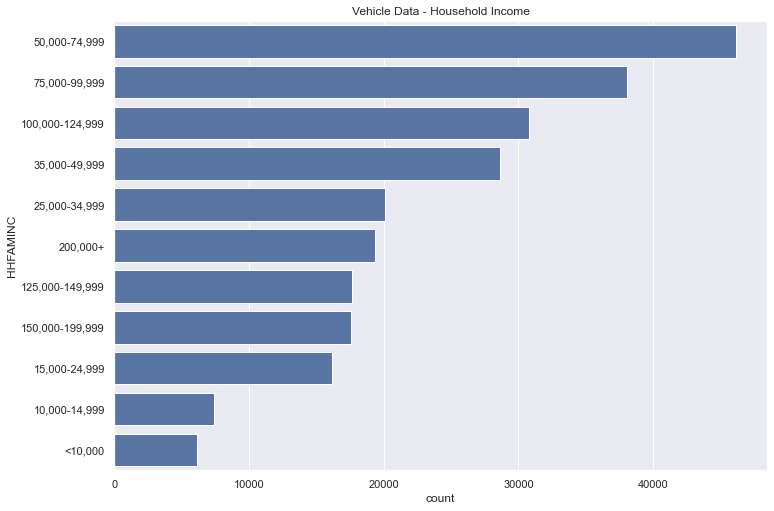

In [28]:
#household income - vehicle
sns.barplot(data=hh_count, x = 'count', y = 'HHFAMINC')
plt.title('Household Data - Household Income')
plt.show()
sns.barplot(data=vehicle_count, x = 'count', y = 'HHFAMINC')
plt.title('Vehicle Data - Household Income')
plt.show

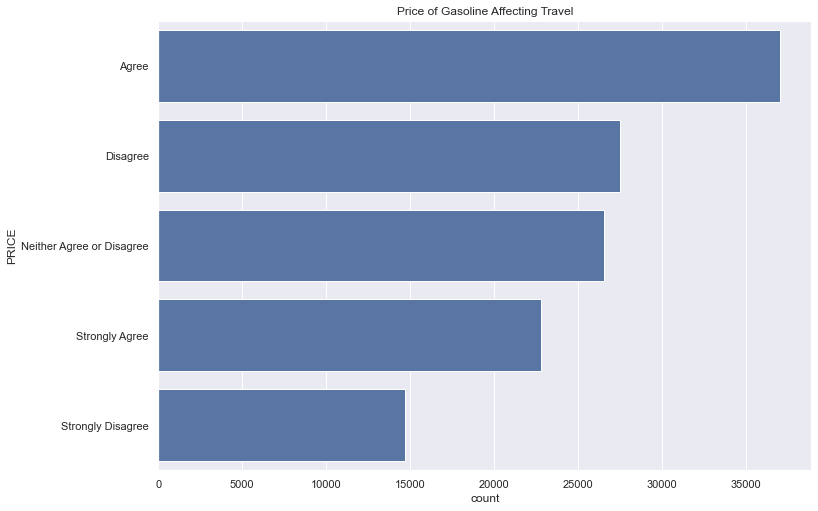

In [29]:
price_count = household_df[household_df['PRICE'] > 0]['PRICE'].replace({1: 'Strongly Agree', 2: 'Agree', 
                                               3: 'Neither Agree or Disagree', 4: 'Disagree', 5: 'Strongly Disagree'}).value_counts().reset_index()

sns.barplot(data=price_count, x = 'count', y = 'PRICE')
plt.title('Price of Gasoline Affecting Travel')
plt.show()

In [36]:
state_freq = vehicle_df['HHSTATE'].value_counts().to_frame().reset_index()
fig = px.choropleth(locations=state_freq['HHSTATE'], locationmode="USA-states", 
                    color=state_freq['count'], color_continuous_scale="Blues", scope="usa", title = 'Vehicle Data - Household State Count')
fig.show()

state_freq = household_df['HHSTATE'].value_counts().to_frame().reset_index()
fig = px.choropleth(locations=state_freq['HHSTATE'], locationmode="USA-states", 
                    color=state_freq['count'], color_continuous_scale="oranges", scope="usa", title = 'Household Data - Household State Count')
fig.show()

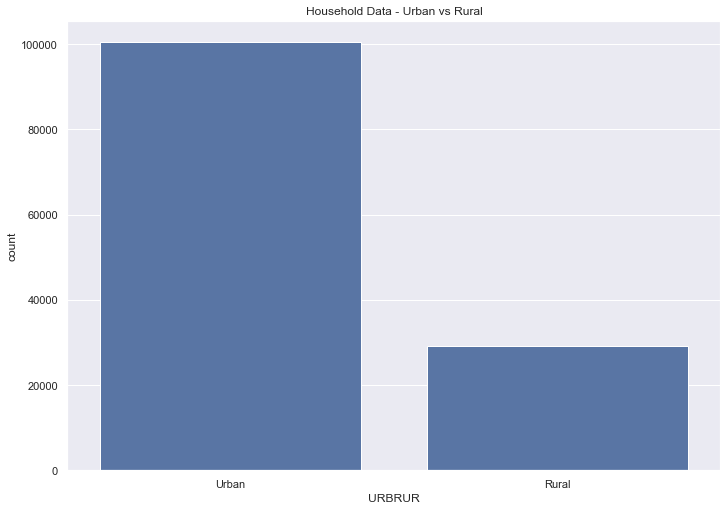

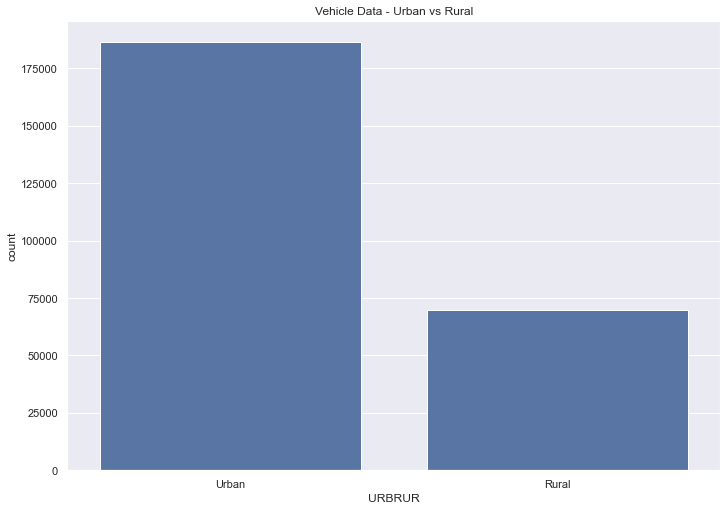

In [25]:
#urban vs rural
hh_count = household_df['URBRUR'].replace({1: 'Urban', 2: 'Rural'}).value_counts().to_frame().reset_index()
sns.barplot(data = hh_count, x = 'URBRUR', y = 'count')
plt.title('Household Data - Urban vs Rural')
plt.show()
area_count = vehicle_df['URBRUR'].replace({1: 'Urban', 2: 'Rural'}).value_counts().to_frame().reset_index()
sns.barplot(data = area_count, x = 'URBRUR', y = 'count')
plt.title('Vehicle Data - Urban vs Rural')
plt.show()

## Bivariate Analysis

Looking at respondent's background, any correlations to vehicle behavior?

Text(0.5, 1.0, 'Household Income and Annual Fuel Expenditures (USD)')

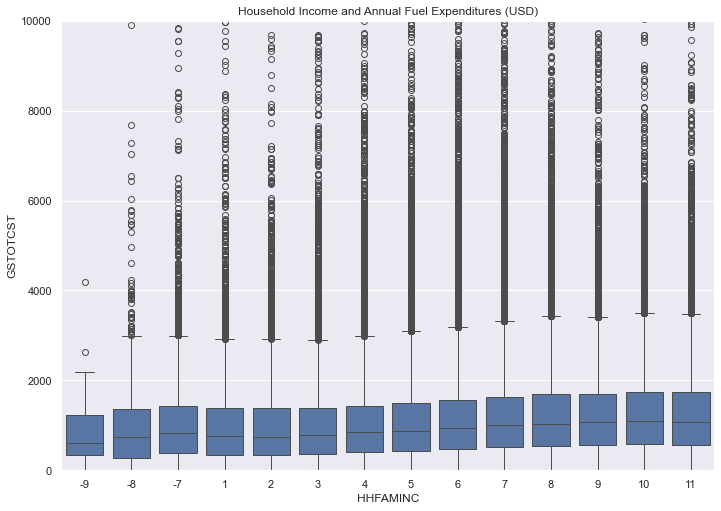

In [54]:
#hh income vs annual fuel expenditures (boxplot)
sns.boxplot(data = vehicle_df[['HHFAMINC', 'GSTOTCST']],  x = 'HHFAMINC', y= 'GSTOTCST')
plt.ylim(0,10000)
plt.title('Household Income and Annual Fuel Expenditures (USD)')

In [35]:
avg_gas_exp = vehicle_df[['HHSTATE', 'GSTOTCST']].groupby('HHSTATE').mean().reset_index()
fig = px.choropleth(locations=avg_gas_exp['HHSTATE'], locationmode="USA-states", 
                    color=avg_gas_exp['GSTOTCST'], color_continuous_scale="Greens", scope="usa", 
                    title = 'Vehicle Data - Average Annual Gas Expenditures (USD)')
fig.show()

Text(0.5, 1.0, 'Household Income and Gas Price Affect')

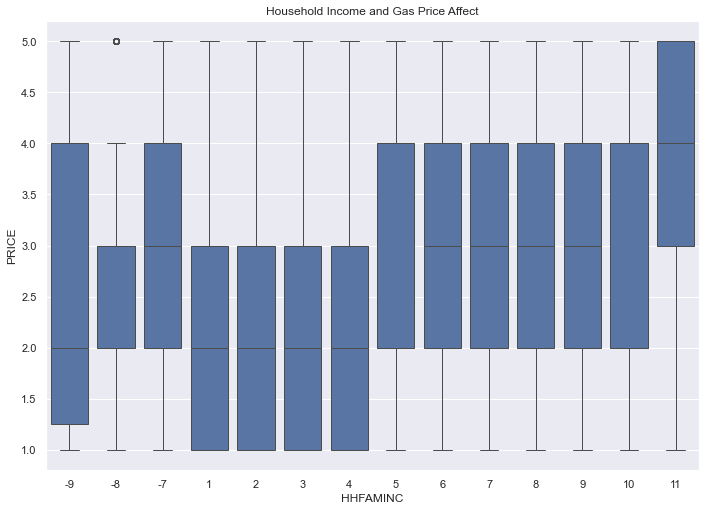

In [53]:
#price opinion vs income
sns.boxplot(data = household_df[household_df['PRICE']>0][['HHFAMINC', 'PRICE']],  x = 'HHFAMINC', y= 'PRICE')
plt.title('Household Income and Gas Price Affect')

Text(0.5, 1.0, 'Vehicle Fuel Type - Annual Mile Estimate')

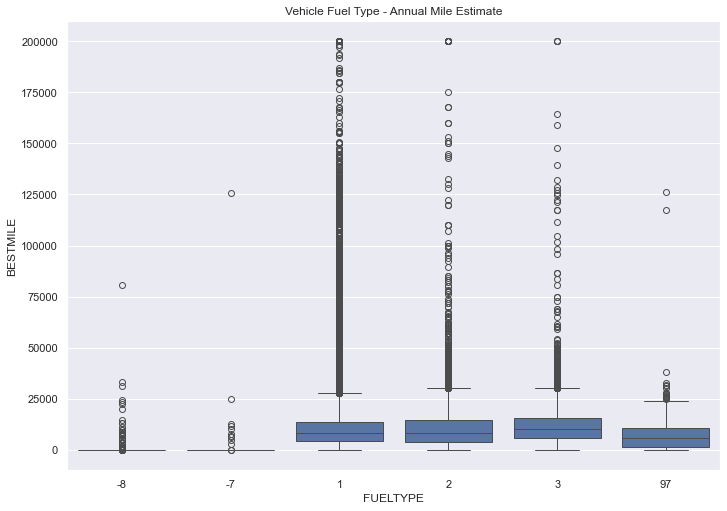

In [55]:
sns.boxplot(data = vehicle_df[['FUELTYPE', 'BESTMILE']],  x = 'FUELTYPE', y= 'BESTMILE')
plt.title('Vehicle Fuel Type - Annual Mile Estimate')

Text(0.5, 1.0, 'Estimate Miles and Gas Expenditures')

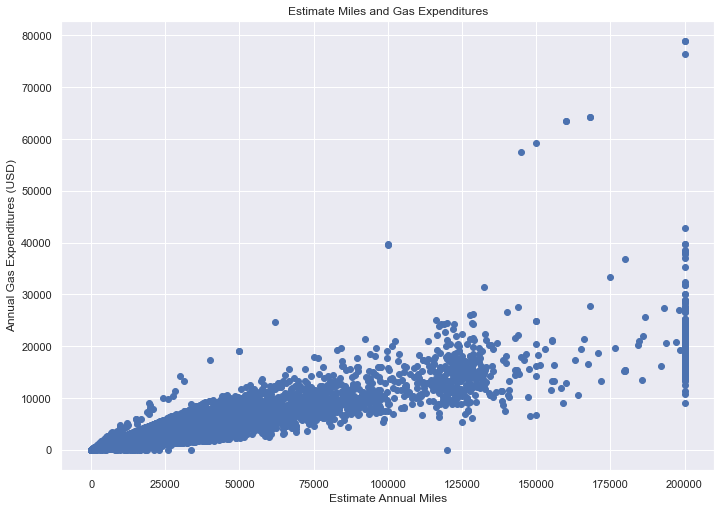

In [56]:
plt.scatter(vehicle_df['BESTMILE'], vehicle_df['GSTOTCST'])
plt.xlabel('Estimate Annual Miles')
plt.ylabel('Annual Gas Expenditures (USD)')
plt.title('Estimate Miles and Gas Expenditures')

In [ ]:
#are there overlaps between vehicle and household?
#sns.boxplot(data = vehicle_df[['PRICE', 'GSTOTCST']],  x = 'PRICE', y= 'GSTOTCST')